## Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

import tensorflow as tf
from tensorflow.keras import layers, models

## Load Dataset

In [ ]:
dataset_path = Path("../../dataset")
dl_data_path = dataset_path / "dl_data"

X_train = np.load(dl_data_path / "X_train.npy")
X_validation = np.load(dl_data_path / "X_validation.npy")
X_test = np.load(dl_data_path / "X_test.npy")

y_train = np.load(dl_data_path / "y_train.npy")
y_validation = np.load(dl_data_path / "y_validation.npy")
y_test = np.load(dl_data_path / "y_test.npy")

print("===== Datasets loaded successfully. =====")

===== Datasets loaded successfully. =====


## Preprocessing & Normalization

In [4]:
X_train = X_train.astype(np.float32)
X_validation = X_validation.astype(np.float32)
X_test = X_test.astype(np.float32)

# Calculate statistics only from training data
train_mean = X_train.mean()
train_std = X_train.std()

# Normalize
X_train = (X_train - train_mean) / train_std
X_validation = (X_validation - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

print("===== NORMALIZATION CHECK =====")

print("Train:")
print("Mean:", X_train.mean())
print("Std:", X_train.std())

print("\nValidation:")
print("Mean:", X_validation.mean())
print("Std:", X_validation.std())

print("\nTest:")
print("Mean:", X_test.mean())
print("Std:", X_test.std())

===== NORMALIZATION CHECK =====
Train:
Mean: 8.628554e-08
Std: 1.0000006

Validation:
Mean: 0.00015843338
Std: 1.0341631

Test:
Mean: 0.0026376029
Std: 1.0162377


## Add Channel Dimension

In [5]:
X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print("\n===== INCEPTIONTIME INPUT SHAPES =====")

print("X_train:", X_train.shape)
print("X_validation:", X_validation.shape)
print("X_test:", X_test.shape)


===== INCEPTIONTIME INPUT SHAPES =====
X_train: (5969, 9000, 1)
X_validation: (1279, 9000, 1)
X_test: (1280, 9000, 1)


## Inception Module

In [6]:
def inception_module(
    x,
    filters=32,
    kernel_sizes=(41, 21, 11),
    bottleneck_filters=32
):
    
    # Bottleneck
    if x.shape[-1] > 1:
        bottleneck = layers.Conv1D(
            filters=bottleneck_filters,
            kernel_size=1,
            padding="same",
            use_bias=False
        )(x)
    else:
        bottleneck = x

    # Parallel convolutions
    conv_outputs = []

    for kernel_size in kernel_sizes:
        conv = layers.Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            padding="same",
            use_bias=False
        )(bottleneck)

        conv = layers.BatchNormalization()(conv)
        conv = layers.Activation("relu")(conv)

        conv_outputs.append(conv)

    # MaxPooling branch
    pool = layers.MaxPooling1D(
        pool_size=3,
        strides=1,
        padding="same"
    )(x)

    pool = layers.Conv1D(
        filters=filters,
        kernel_size=1,
        padding="same",
        use_bias=False
    )(pool)

    pool = layers.BatchNormalization()(pool)
    pool = layers.Activation("relu")(pool)

    conv_outputs.append(pool)

    # Concatenate all branches
    output = layers.Concatenate(axis=-1)(conv_outputs)

    return output

## Inception Residual Block

In [7]:
def inception_residual_block(
    x,
    filters=32,
    kernel_sizes=(41, 21, 11),
    bottleneck_filters=32
):
    
    input_tensor = x

    x = inception_module(
        x,
        filters=filters,
        kernel_sizes=kernel_sizes,
        bottleneck_filters=bottleneck_filters
    )

    # Number of output channels from Inception module
    output_channels = filters * 4

    # Match residual dimensions if necessary
    if input_tensor.shape[-1] != output_channels:
        input_tensor = layers.Conv1D(
            filters=output_channels,
            kernel_size=1,
            padding="same",
            use_bias=False
        )(input_tensor)

        input_tensor = layers.BatchNormalization()(input_tensor)

    # Residual addition
    x = layers.Add()([x, input_tensor])

    x = layers.Activation("relu")(x)

    return x

## Build InceptionTime Model

In [8]:
inputs = layers.Input(shape=(9000, 1))

x = inputs

# Initial convolution
x = layers.Conv1D(
    filters=32,
    kernel_size=7,
    padding="same",
    use_bias=False
)(x)

x = layers.BatchNormalization()(x)
x = layers.Activation("relu")(x)


# Inception Residual Block 1
x = inception_residual_block(
    x,
    filters=32,
    kernel_sizes=(41, 21, 11),
    bottleneck_filters=32
)


# Inception Residual Block 2
x = inception_residual_block(
    x,
    filters=32,
    kernel_sizes=(41, 21, 11),
    bottleneck_filters=32
)


# Inception Residual Block 3
x = inception_residual_block(
    x,
    filters=32,
    kernel_sizes=(41, 21, 11),
    bottleneck_filters=32
)


# Global pooling
x = layers.GlobalAveragePooling1D()(x)

# Fully connected layer
x = layers.Dense(
    64,
    activation="relu"
)(x)

# Output
outputs = layers.Dense(
    4,
    activation="softmax"
)(x)


model = models.Model(
    inputs=inputs,
    outputs=outputs,
    name="1D_InceptionTime"
)

model.summary()

Model: "1D_InceptionTime"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 9000, 1)]    0           []                               
                                                                                                  
 conv1d (Conv1D)                (None, 9000, 32)     224         ['input_1[0][0]']                
                                                                                                  
 batch_normalization (BatchNorm  (None, 9000, 32)    128         ['conv1d[0][0]']                 
 alization)                                                                                       
                                                                                                  
 activation (Activation)        (None, 9000, 32)     0           ['batch_normalizat

## Compile Model

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.001
    ),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully.")

Model compiled successfully.


## Callbacks

In [10]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

model_checkpoint = ModelCheckpoint(
    "best_1d_inceptiontime_unweighted.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

print("Callbacks created successfully.")

Callbacks created successfully.


## Train Model

In [13]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_validation, y_validation),
    epochs=50,
    batch_size=8,
    callbacks=[
        early_stopping,
        model_checkpoint
    ],
    verbose=1
)

Epoch 1/50
747/747 [==============================] - ETA: 0s - loss: 0.9800 - accuracy: 0.5805
Epoch 1: val_loss improved from inf to 1.03395, saving model to best_1d_inceptiontime_unweighted.keras
747/747 [==============================] - 223s 286ms/step - loss: 0.9800 - accuracy: 0.5805 - val_loss: 1.0340 - val_accuracy: 0.6005
Epoch 2/50
746/747 [============================>.] - ETA: 0s - loss: 0.9324 - accuracy: 0.6116
Epoch 2: val_loss improved from 1.03395 to 1.03317, saving model to best_1d_inceptiontime_unweighted.keras
747/747 [==============================] - 159s 213ms/step - loss: 0.9330 - accuracy: 0.6115 - val_loss: 1.0332 - val_accuracy: 0.5856
Epoch 3/50
747/747 [==============================] - ETA: 0s - loss: 0.9062 - accuracy: 0.6160
Epoch 3: val_loss improved from 1.03317 to 0.85982, saving model to best_1d_inceptiontime_unweighted.keras
747/747 [==============================] - 177s 237ms/step - loss: 0.9062 - accuracy: 0.6160 - val_loss: 0.8598 - val_accurac

## Test Evaluation

In [14]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=1
)

print("===== 1D INCEPTIONTIME TEST RESULTS =====")

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

40/40 [==============================] - 6s 145ms/step - loss: 0.7191 - accuracy: 0.6969
===== 1D INCEPTIONTIME TEST RESULTS =====
Test Loss: 0.7191
Test Accuracy: 0.6969


## Predictions & Confusion Matrix

In [15]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

y_pred_prob = model.predict(
    X_test,
    verbose=1
)

y_pred = np.argmax(
    y_pred_prob,
    axis=1
)

cm = confusion_matrix(
    y_test,
    y_pred
)

print("===== INCEPTIONTIME CONFUSION MATRIX =====")
print(cm)

40/40 [==============================] - 6s 149ms/step
===== INCEPTIONTIME CONFUSION MATRIX =====
[[723  14  17   8]
 [ 22  79  11   1]
 [232  56  73   2]
 [ 20   2   3  17]]


## Plot Confusion Matrix

<Figure size 700x600 with 0 Axes>

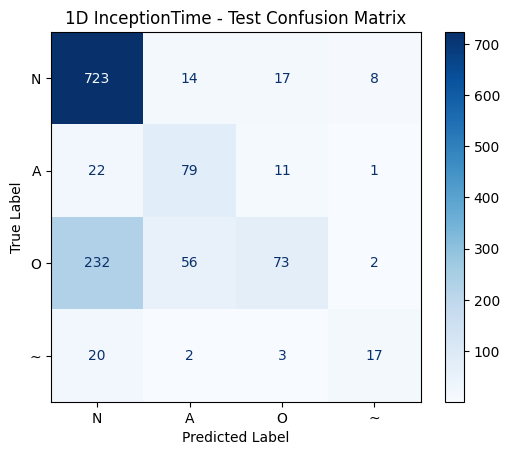

In [16]:
class_names = ["N", "A", "O", "~"]

plt.figure(figsize=(7, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(
    cmap="Blues",
    values_format="d"
)

plt.title("1D InceptionTime - Test Confusion Matrix")

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

## Classification Report

In [17]:
print("===== INCEPTIONTIME CLASSIFICATION REPORT =====")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=class_names,
        digits=4
    )
)

===== INCEPTIONTIME CLASSIFICATION REPORT =====
              precision    recall  f1-score   support

           N     0.7252    0.9488    0.8221       762
           A     0.5232    0.6991    0.5985       113
           O     0.7019    0.2011    0.3126       363
           ~     0.6071    0.4048    0.4857        42

    accuracy                         0.6969      1280
   macro avg     0.6394    0.5634    0.5547      1280
weighted avg     0.6969    0.6969    0.6468      1280



## Loss Curve

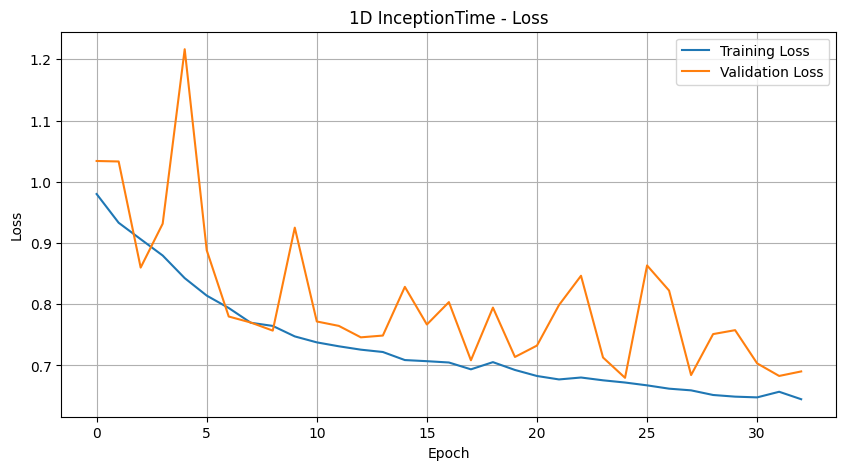

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("1D InceptionTime - Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid()

plt.show()

## Accuracy Curve

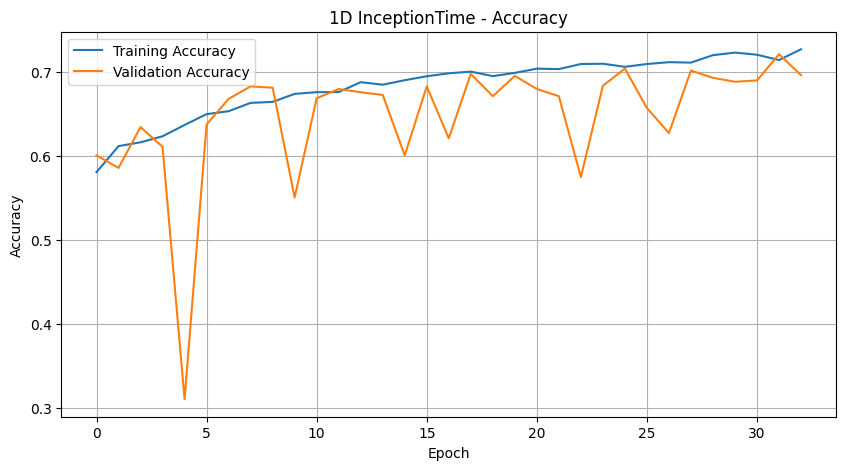

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title("1D InceptionTime - Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()
plt.grid()

plt.show()